# EDA & Class Separability

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Dataset.csv")

df.head()

,S No,binary bit R,Binary bit S,Analog value,Analog Voltage,NTU
0,1,1,1,125,0.610352,1-2NTU
1,2,0,0,101,0.493164,1-2NTU
2,3,1,1,123,0.600586,1-2NTU
3,4,0,0,101,0.493164,1-2NTU
4,5,0,0,95,0.463867,1-2NTU


## 1. Class Wise Analysis

### 1.1 Class Distribution

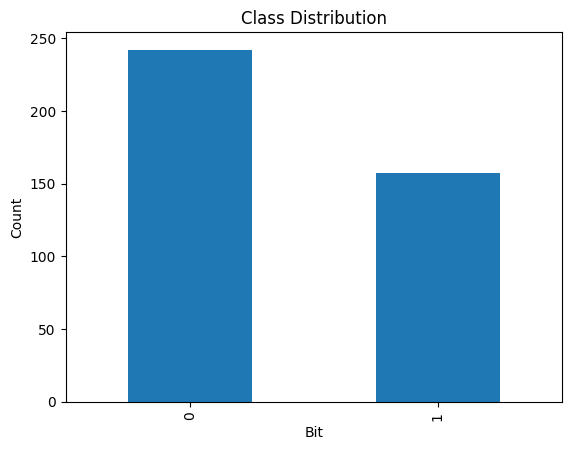

In [4]:
df["Binary bit S"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Bit")
plt.ylabel("Count")

plt.show()

### 1.2 Correct vs Wrong Detection

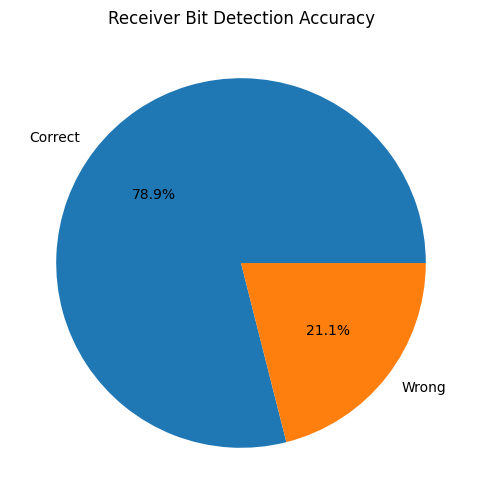

In [13]:
correct_count = len(
    df[
        df["Binary bit S"]
        ==
        df["binary bit R"]
    ]
)

wrong_count = len(
    df[
        df["Binary bit S"]
        !=
        df["binary bit R"]
    ]
)

plt.figure(figsize=(6,6))

plt.pie(
    [correct_count, wrong_count],
    labels=["Correct","Wrong"],
    autopct="%1.1f%%"
)

plt.title(
    "Receiver Bit Detection Accuracy"
)

plt.show()

### 1.3 Bit-wise Correct & Wrong

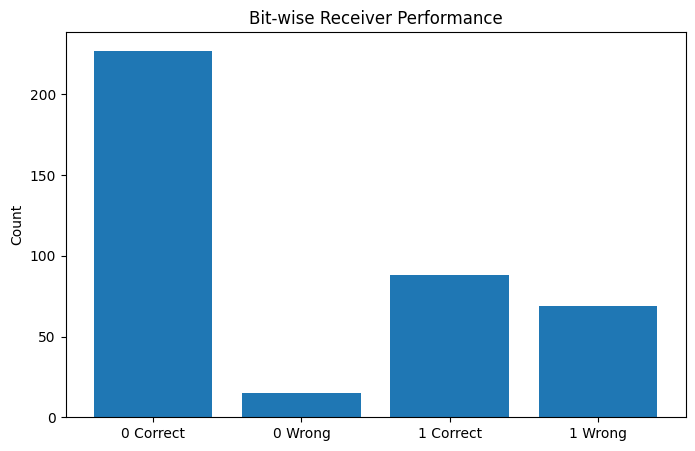

In [15]:
actual0_correct = len(
    df[
        (df["Binary bit S"]==0)
        &
        (df["binary bit R"]==0)
    ]
)

actual0_wrong = len(
    df[
        (df["Binary bit S"]==0)
        &
        (df["binary bit R"]==1)
    ]
)

actual1_correct = len(
    df[
        (df["Binary bit S"]==1)
        &
        (df["binary bit R"]==1)
    ]
)

actual1_wrong = len(
    df[
        (df["Binary bit S"]==1)
        &
        (df["binary bit R"]==0)
    ]
)

labels = [
    "0 Correct",
    "0 Wrong",
    "1 Correct",
    "1 Wrong"
]

counts = [
    actual0_correct,
    actual0_wrong,
    actual1_correct,
    actual1_wrong
]

plt.figure(figsize=(8,5))

plt.bar(labels, counts)

plt.title("Bit-wise Receiver Performance")

plt.ylabel("Count")

plt.show()

### 1.4 NTU-wise Bit Detection Performance

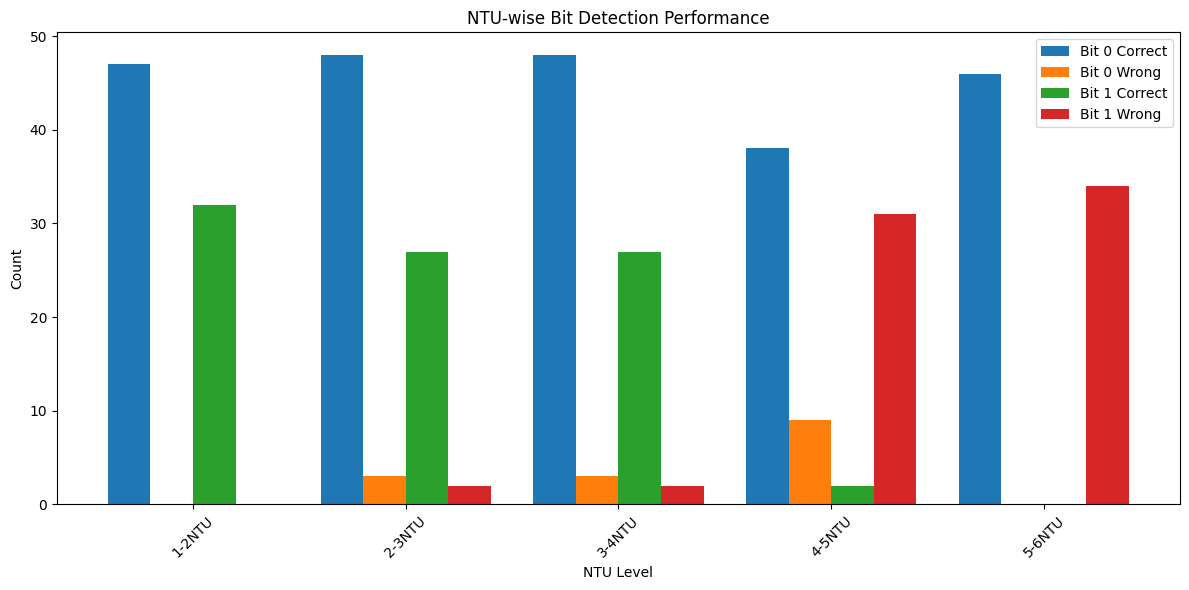

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ntu_levels = df["NTU"].unique()

bit0_correct = []
bit0_wrong = []
bit1_correct = []
bit1_wrong = []

for ntu in ntu_levels:

    temp = df[df["NTU"] == ntu]

    bit0_correct.append(
        len(temp[
            (temp["Binary bit S"] == 0) &
            (temp["binary bit R"] == 0)
        ])
    )

    bit0_wrong.append(
        len(temp[
            (temp["Binary bit S"] == 0) &
            (temp["binary bit R"] == 1)
        ])
    )

    bit1_correct.append(
        len(temp[
            (temp["Binary bit S"] == 1) &
            (temp["binary bit R"] == 1)
        ])
    )

    bit1_wrong.append(
        len(temp[
            (temp["Binary bit S"] == 1) &
            (temp["binary bit R"] == 0)
        ])
    )

x = np.arange(len(ntu_levels))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*width, bit0_correct, width,
        label="Bit 0 Correct")

plt.bar(x - 0.5*width, bit0_wrong, width,
        label="Bit 0 Wrong")

plt.bar(x + 0.5*width, bit1_correct, width,
        label="Bit 1 Correct")

plt.bar(x + 1.5*width, bit1_wrong, width,
        label="Bit 1 Wrong")

plt.xticks(x, ntu_levels, rotation=45)

plt.xlabel("NTU Level")
plt.ylabel("Count")
plt.title("NTU-wise Bit Detection Performance")

plt.legend()

plt.tight_layout()
plt.show()

# 2. Analog Value Distribution

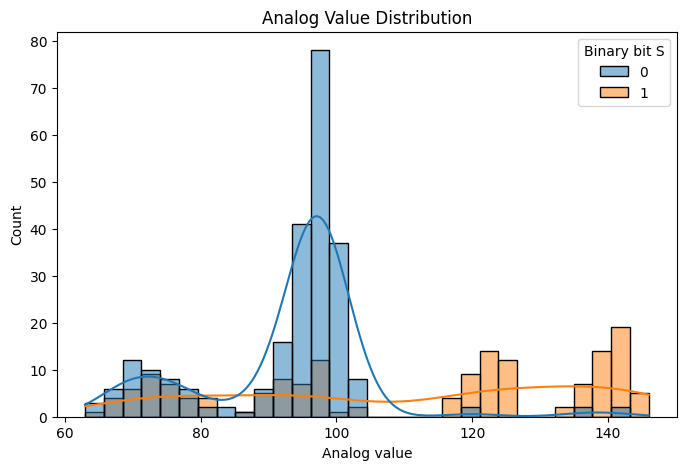

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Analog value",
    hue="Binary bit S",
    kde=True
)

plt.title("Analog Value Distribution")

plt.show()

## 3. NTU-wise Distribution

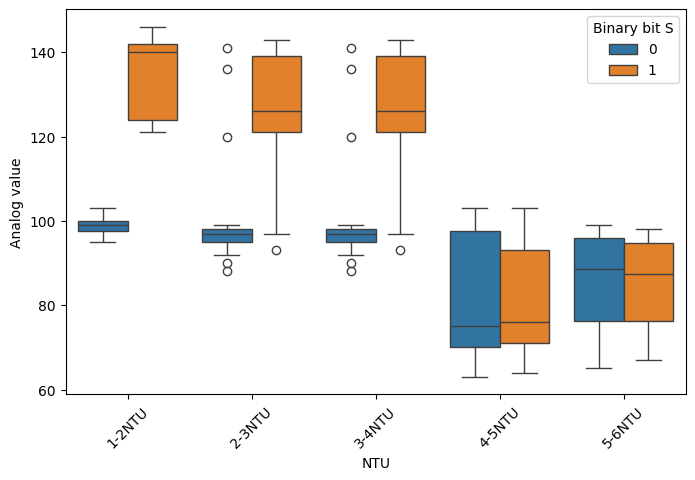

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="NTU",
    y="Analog value",
    hue="Binary bit S",
    data=df
)

plt.xticks(rotation=45)

plt.show()

## 5. Correlation Map

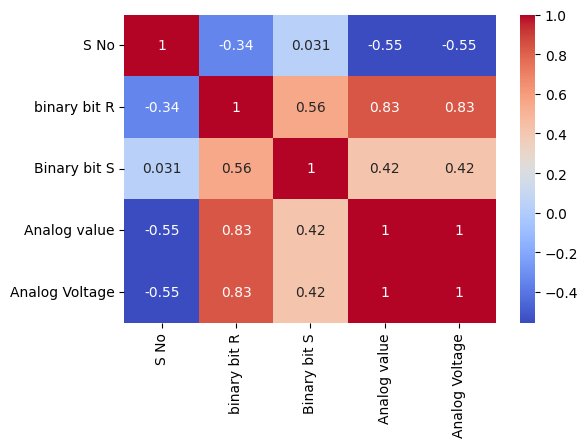

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()